___ACCIONES COLOMBIA___

In [9]:
#Cargar Librerías
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import openpyxl

In [10]:
# Montar unidad
#from google.colab import drive
#drive.mount('/content/drive')

In [12]:
# Leemos datos viejos
oldata = pd.read_excel("Data\Acciones_colab.xlsx")

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\ypalacios\AppData\Local\Temp\ipykernel_5748\374762072.py:2: SyntaxWarning: invalid escape sequence '\A'
  oldata = pd.read_excel("Data\Acciones_colab.xlsx")


In [15]:
# Transformación de los nuevos datos (archivo mas reciente)
carpeta = Path("Data\Input")
archivo_csv = max(carpeta.glob("*.csv"), key=lambda f: f.stat().st_mtime)
nombre_sin_extension = archivo_csv.stem
newdata = pd.read_csv(archivo_csv, sep=';')

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\ypalacios\AppData\Local\Temp\ipykernel_5748\762907244.py:2: SyntaxWarning: invalid escape sequence '\I'
  carpeta = Path("Data\Input")


In [16]:
# Lectura de los nuevos datos
columnas = [
    "Nemotécnico",
    "Precios (último /cierre)",
    "Variación porcentual",
    "Volúmenes",
    "Cantidad",
    "Variación absoluta",
    "Precio apertura",
    "Precio máximo",
    "Precio mínimo",
    "Precio promedio",
    "Emisor / nombre",
    "Tipo  Activo"          # <- nombre de la columna faltante
]

newdata = pd.read_csv(
    archivo_csv,
    sep=";",
    decimal=",",
    names=columnas,
    header=0,
)

In [17]:
# Extraemos nombre del nuevo archivo para tomar fecha
fecha = re.search(r"\d{8}", archivo_csv.stem).group()
fecha = pd.to_datetime(fecha, format="%Y%m%d")
newdata["Fecha"] = fecha

In [18]:
# Convertir fechas
oldata["Fecha"] = pd.to_datetime(oldata["Fecha"])
newdata["Fecha"] = pd.to_datetime(newdata["Fecha"])

In [19]:
oldata.head(1)

,Fecha,Nemotécnico,Precios (último /cierre),Variación porcentual,Volúmenes,Cantidad,Variación absoluta,Precio apertura,Precio máximo,Precio mínimo,Precio promedio,Emisor / nombre,Tipo Activo
0,2026-01-19,CELSIA,5080.0,0.4,737046200.0,145935.0,20,NaN,5080.0,5010.0,5050.51,NaN,NaN


In [20]:
newdata.head(1)

,Nemotécnico,Precios (último /cierre),Variación porcentual,Volúmenes,Cantidad,Variación absoluta,Precio apertura,Precio máximo,Precio mínimo,Precio promedio,Emisor / nombre,Tipo Activo,Fecha
0,ECOPETROL,2590.0,"-0,58",3.706944e+10,14209170,-15.0,2610.0,2640.0,2590.0,-,ECOPETROL,EQTY,2026-07-24


In [21]:
data = pd.concat([oldata, newdata])

In [23]:
data.tail(5)

,Fecha,Nemotécnico,Precios (último /cierre),Variación porcentual,Volúmenes,Cantidad,Variación absoluta,Precio apertura,Precio máximo,Precio mínimo,Precio promedio,Emisor / nombre,Tipo Activo
32,2026-07-24,PFCEMARGOS,11660.0,-,10151540.0,925.0,0.0,11660.0,11660.0,11660.0,-,CEMENTOS ARGOS,EQTY
33,2026-07-24,BVC,15840.0,-,8272740.0,529.0,0.0,15840.0,15840.0,15840.0,-,BOLSA DE VALORES DE COLOMBIA,EQTY
34,2026-07-24,ETB,68.5,"5,38",5118928.5,74922.0,3.5,68.5,68.5,68.5,-,ETB,EQTY
35,2026-07-24,HCOLSEL,26232.5,-,1952361.0,78.0,0.0,26232.5,26232.5,26232.5,-,FONDO BURSATIL GLOBAL X COLOMBIA SELECT DE S&P,EQTY
36,2026-07-24,POPULAR,135.0,-,135000.0,1000.0,0.0,135.0,135.0,135.0,-,BANCO POPULAR,EQTY


In [24]:
Cemargos = data[data["Nemotécnico"] == "CEMARGOS"]
Cibest = data[data["Nemotécnico"] == "CIBEST"]
Ecopetrol = data[data["Nemotécnico"] == "ECOPETROL"]
GrupoAval = data[data["Nemotécnico"] == "GRUPOAVAL"]
Isa = data[data["Nemotécnico"] == "ISA"]
PFaval = data[data["Nemotécnico"] == "PFAVAL"]
PFDavigroup = data[data["Nemotécnico"] == "PFDAVIGRP"]
COLCAP = data[data["Nemotécnico"] == "ICOLCAP"]

In [25]:
def grafica(dfinput, colores):

  # Graficar
  titulo = dfinput["Nemotécnico"].iloc[0]
  plt.figure(figsize=(12,6))
  plt.plot(dfinput["Fecha"], dfinput["Precios (último /cierre)"], color = colores, linewidth=2)

  plt.title(titulo)
  plt.xlabel("Fecha")
  plt.ylabel("Precio Cierre")
  plt.grid(True)

  plt.show()


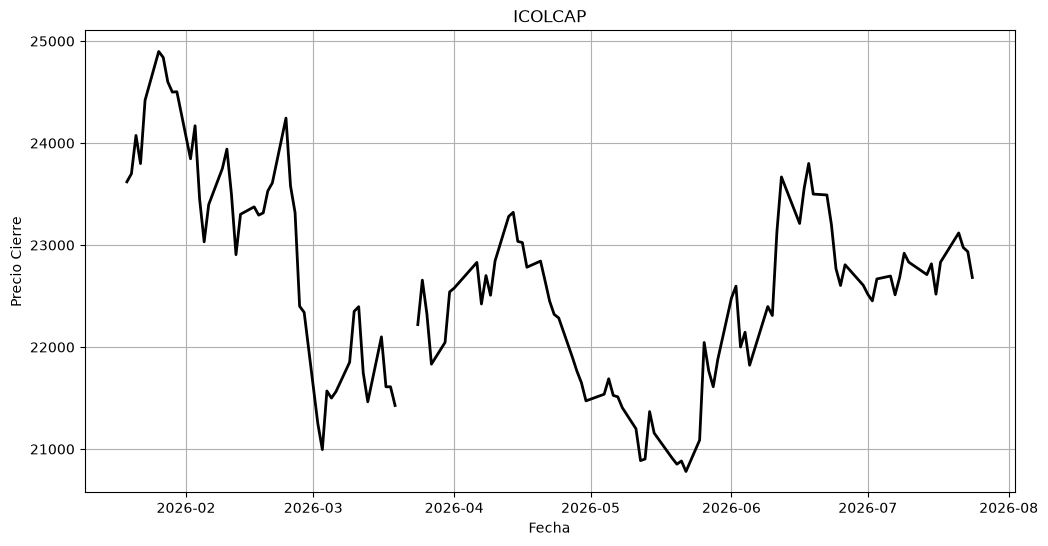

In [26]:
grafica(COLCAP, "black")

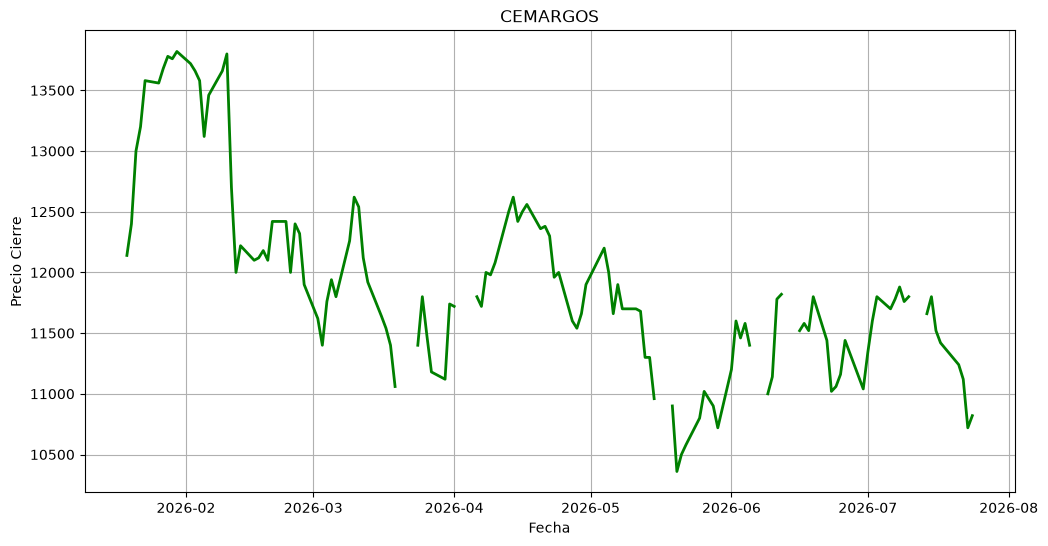

In [27]:
grafica(Cemargos, "green")

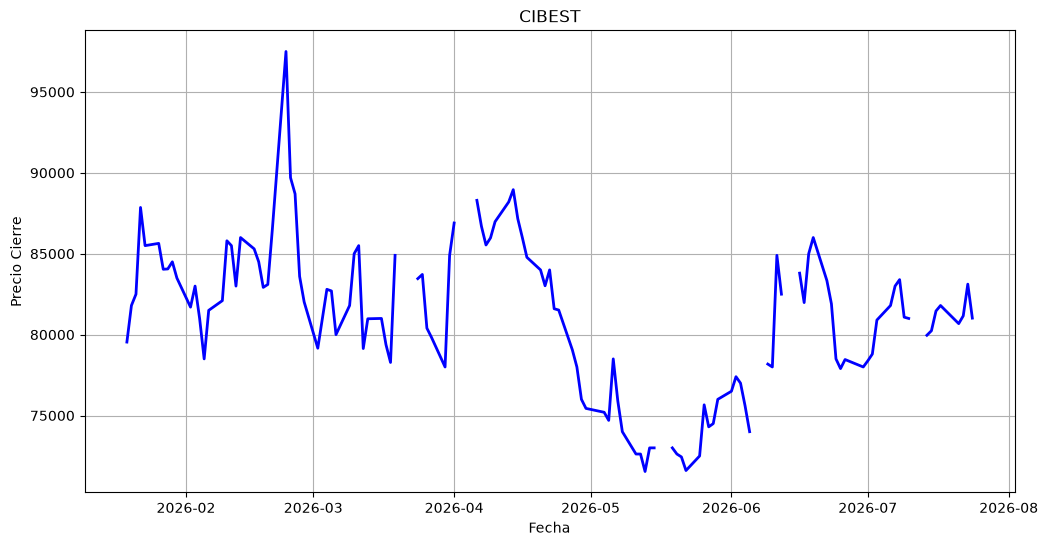

In [28]:
grafica(Cibest, "blue")

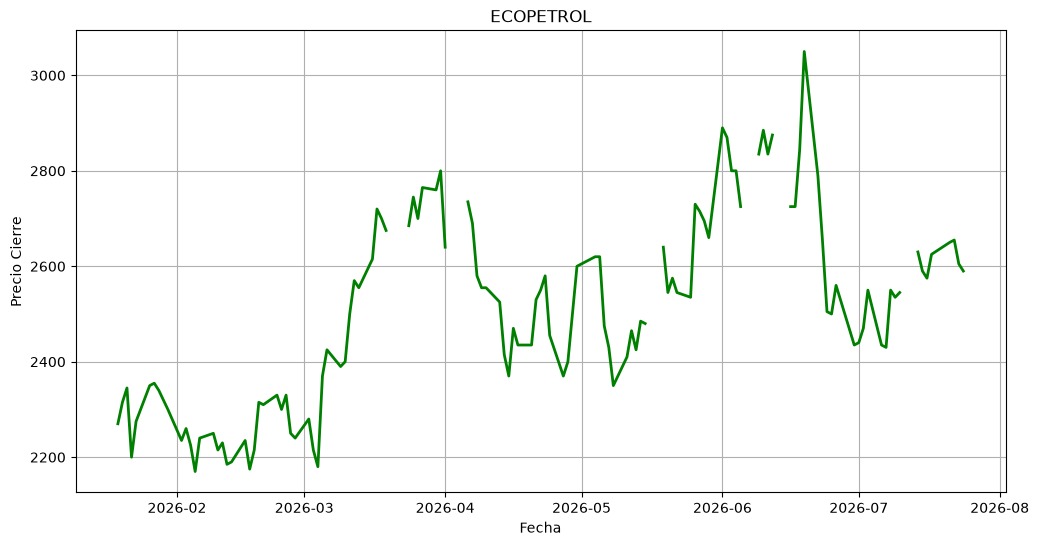

In [29]:
grafica(Ecopetrol, "green")

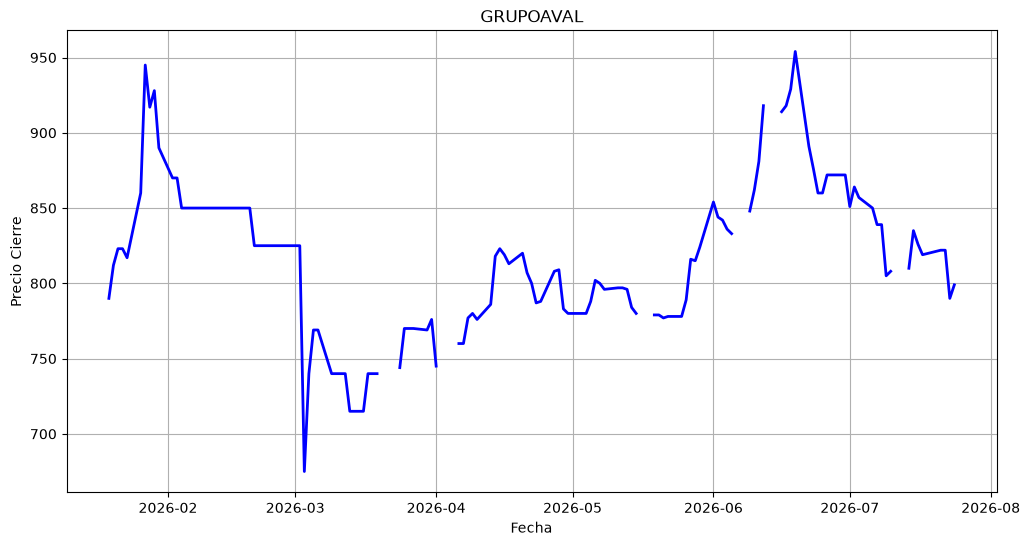

In [30]:
grafica(GrupoAval, "blue")

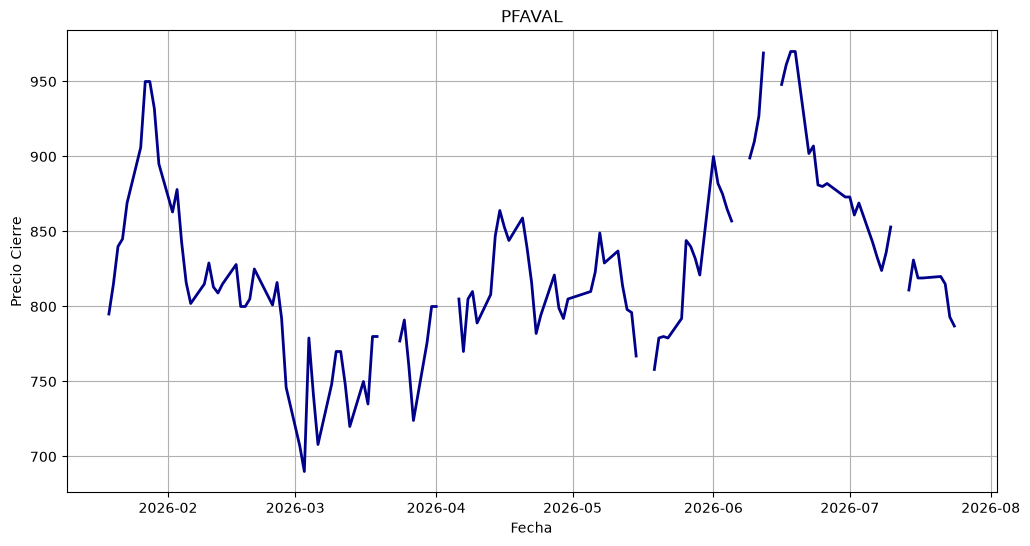

In [31]:
grafica(PFaval, "darkblue")

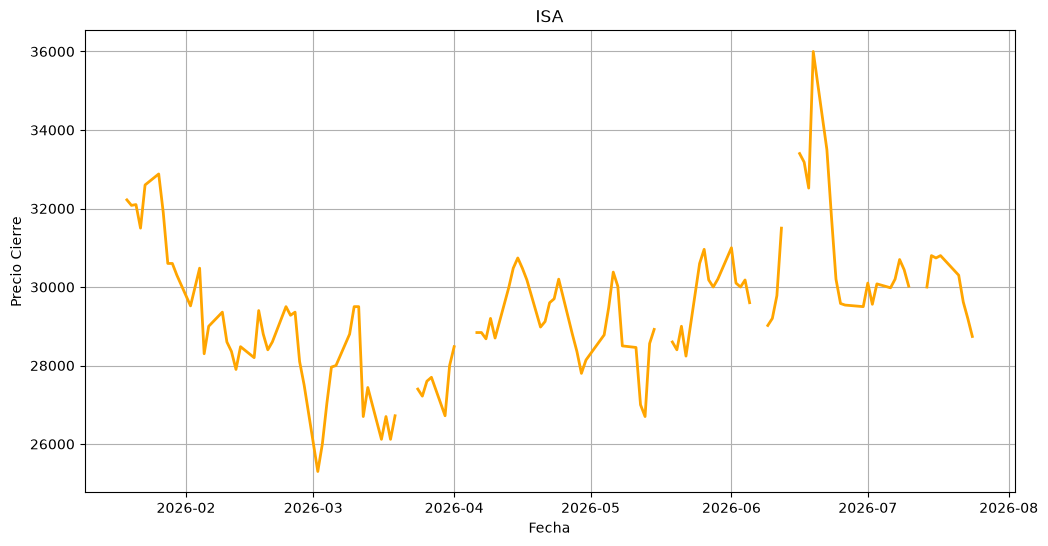

In [32]:
grafica(Isa, "orange")

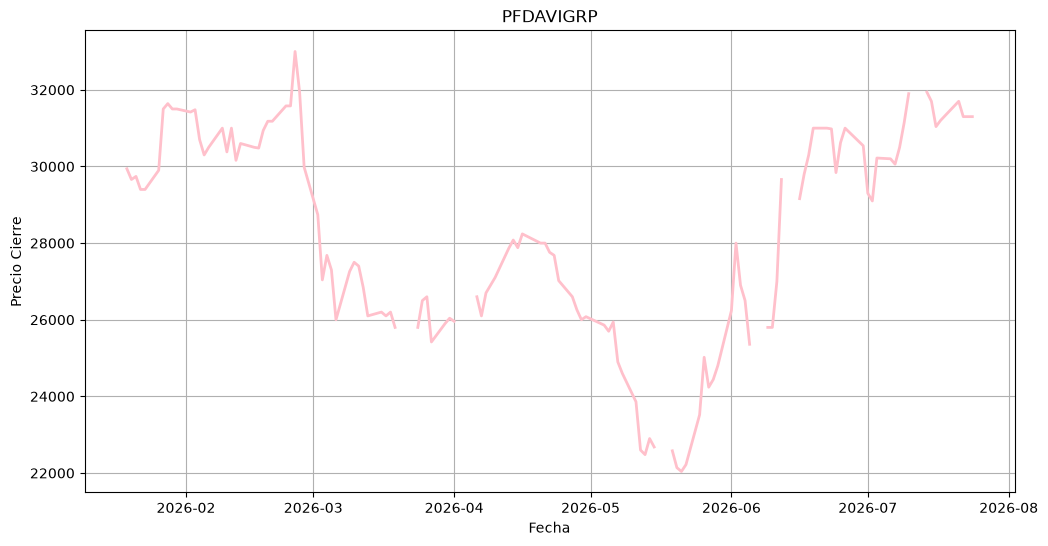

In [33]:
grafica(PFDavigroup, "pink")

In [35]:
data.to_excel("Data\Acciones_colab.xlsx", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\ypalacios\AppData\Local\Temp\ipykernel_5748\1901953304.py:1: SyntaxWarning: invalid escape sequence '\A'
  data.to_excel("Data\Acciones_colab.xlsx", index=False)
